In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn import metrics
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train Shape: (50000, 32, 32, 3)
Test Shape: (10000, 32, 32, 3)
Image Size: 32x32
Classes: 100


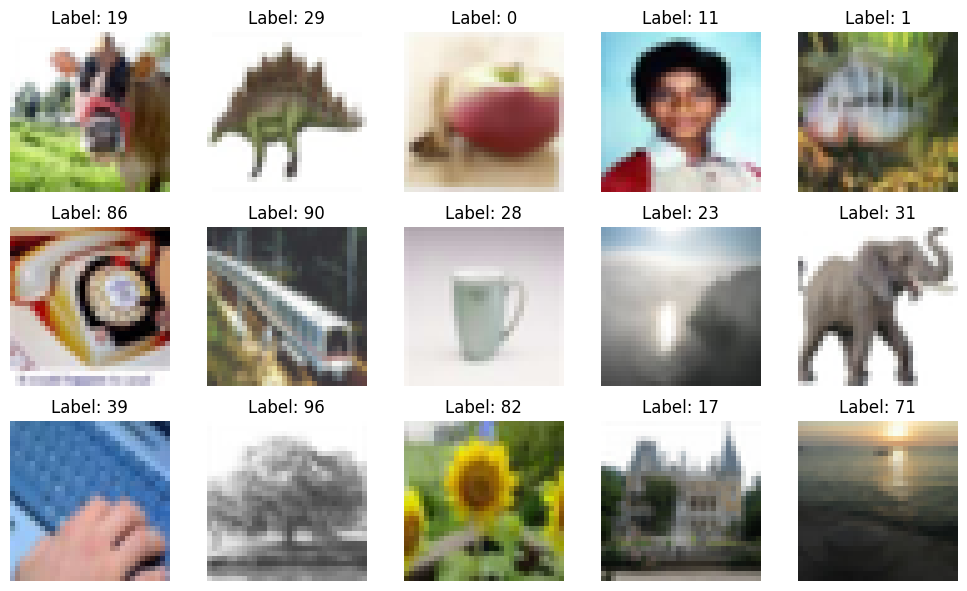

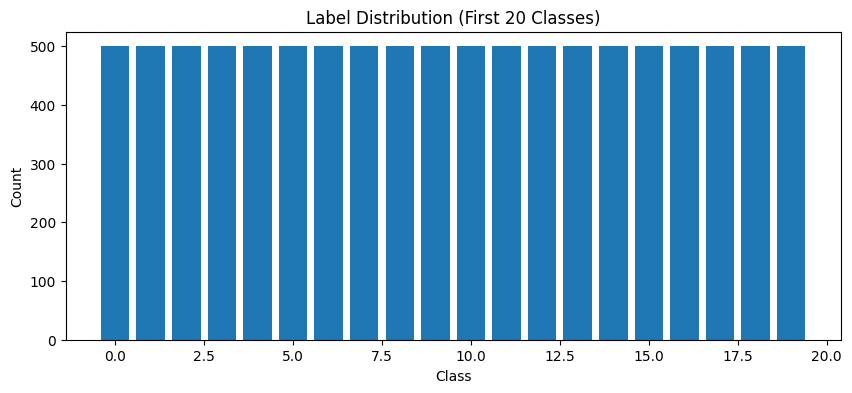

In [ ]:

# Load CIFAR-100
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()

print(f"Train Shape: {X_train.shape}")
print(f"Test Shape: {X_test.shape}")
print(f"Image Size: {X_train.shape[1]}x{X_train.shape[2]}")
print(f"Classes: 100")

# Show sample images
fig, axes = plt.subplots(3, 5, figsize=(10,6))
axes = axes.ravel()

for i in range(15):
    axes[i].imshow(X_train[i])
    axes[i].set_title(f"Label: {y_train[i][0]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Label distribution
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10,4))
plt.bar(unique[:20], counts[:20])  # show first 20 classes
plt.title("Label Distribution (First 20 Classes)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
# Flatten images
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Normalize
X_train_flat = X_train_flat / 255.0
X_test_flat = X_test_flat / 255.0

# PCA
n_components = 200
pca = PCA(n_components=n_components, whiten=True, random_state=42)

X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

print("Explained Variance:", sum(pca.explained_variance_ratio_))

# One-hot encoding
encoder = OneHotEncoder(sparse_output=False)

y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)



Explained Variance: 0.9496414055093174


In [ ]:
mlp_model = Sequential([
    Dense(128, activation='relu', input_shape=(n_components,)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(100, activation='softmax')
])

mlp_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_mlp = mlp_model.fit(X_train_pca, y_train_enc,
                            epochs=30,
                            batch_size=32,
                            validation_split=0.2)

# Evaluate
loss, acc = mlp_model.evaluate(X_test_pca, y_test_enc)
print("MLP Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.0390 - loss: 4.4494 - val_accuracy: 0.1103 - val_loss: 3.9724
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1135 - loss: 3.8589 - val_accuracy: 0.1502 - val_loss: 3.6671
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1470 - loss: 3.6528 - val_accuracy: 0.1671 - val_loss: 3.5657
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1652 - loss: 3.5340 - val_accuracy: 0.1843 - val_loss: 3.4844
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1758 - loss: 3.4557 - val_accuracy: 0.1940 - val_loss: 3.4347
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1871 - loss: 3.3912 - val_accuracy: 0.1934 - val_loss: 3.4027
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1955 - loss: 3.3447 - val_accuracy: 0.2011 - val_loss: 3.3673
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2001 - loss: 3.3078 - 

In [ ]:
import pandas as pd

ann_data = {
    "Component": [
        "Input Layer (3072)",
        "Dense (512)",
        "BatchNormalization",
        "Dropout (0.4)",
        "Dense (256)",
        "BatchNormalization",
        "Dropout (0.4)",
        "Dense (128)",
        "Dropout (0.3)",
        "Dense (100, Softmax)"
    ],

    "Description": [
        "Flattened image input",
        "Fully connected layer",
        "Normalizes activations",
        "Regularization",
        "Hidden layer",
        "Normalizes activations",
        "Regularization",
        "Hidden layer",
        "Regularization",
        "Output layer"
    ],

    "Purpose": [
        "Accepts image as vector",
        "Learns complex patterns",
        "Stabilizes training",
        "Prevents overfitting",
        "Further feature learning",
        "Improves convergence",
        "Avoids overfitting",
        "Refines features",
        "Improves generalization",
        "Classifies into 100 classes"
    ]
}

ann_df = pd.DataFrame(ann_data)
ann_df

,Component,Description,Purpose
0,Input Layer (3072),Flattened image input,Accepts image as vector
1,Dense (512),Fully connected layer,Learns complex patterns
2,BatchNormalization,Normalizes activations,Stabilizes training
3,Dropout (0.4),Regularization,Prevents overfitting
4,Dense (256),Hidden layer,Further feature learning
5,BatchNormalization,Normalizes activations,Improves convergence
6,Dropout (0.4),Regularization,Avoids overfitting
7,Dense (128),Hidden layer,Refines features
8,Dropout (0.3),Regularization,Improves generalization
9,"Dense (100, Softmax)",Output layer,Classifies into 100 classes


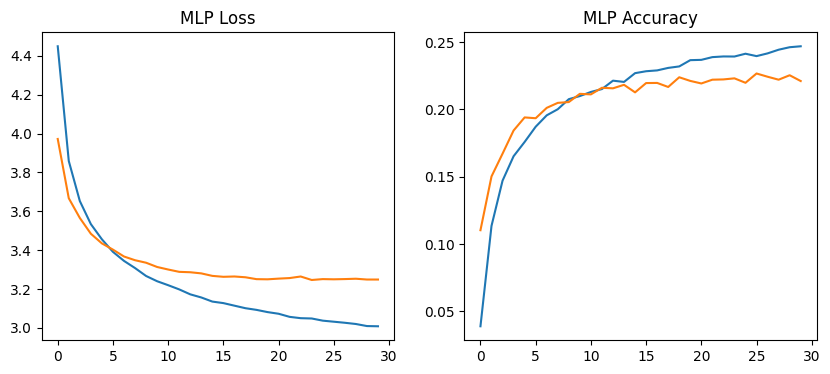

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history_mlp.history['loss'])
plt.plot(history_mlp.history['val_loss'])
plt.title("MLP Loss")

plt.subplot(1,2,2)
plt.plot(history_mlp.history['accuracy'])
plt.plot(history_mlp.history['val_accuracy'])
plt.title("MLP Accuracy")

plt.show()


### Visualizing Model Training History

It's crucial to visualize the training and validation metrics (accuracy and loss) over epochs to understand how well your model is learning and to detect issues like overfitting or underfitting. The following function `plot_training` simplifies this process.

In [ ]:
import matplotlib.pyplot as plt

def plot_training(history, model_name):
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{model_name} Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{model_name} Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper right')

    plt.tight_layout()
    plt.show()

Now, let's use this function to visualize the training history of your MLP and CNN models. Remember that `history_mlp` stores the training logs for the MLP, and `history_cnn` stores them for the CNN.

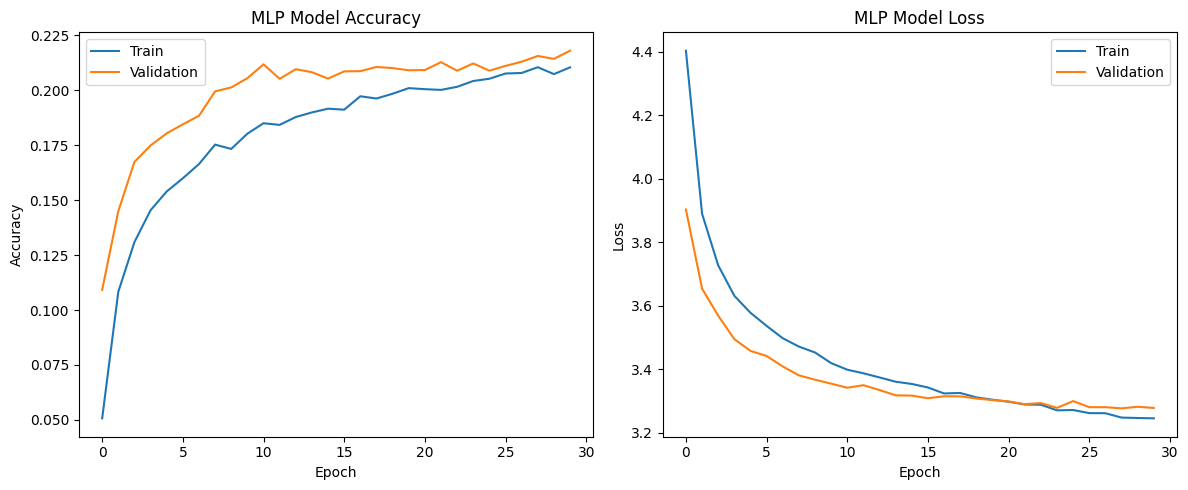

NameError: name 'history_cnn' is not defined

In [ ]:
# Plot the training history for the MLP model
plot_training(history_mlp, "MLP")

# Plot the training history for the CNN model
plot_training(history_cnn, "CNN")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import tensorflow as tf

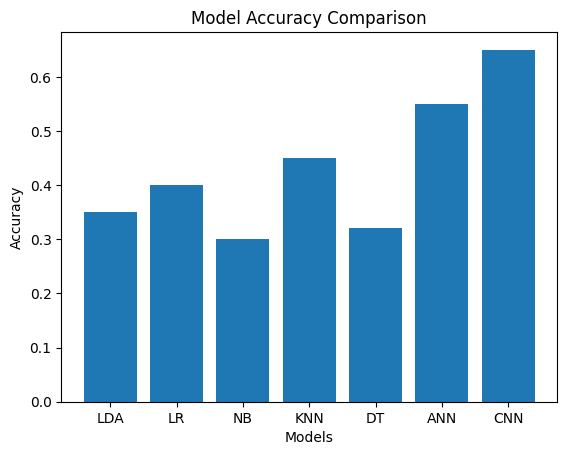

In [ ]:
import matplotlib.pyplot as plt

# Replace with YOUR actual results
models = ['LDA', 'LR', 'NB', 'KNN', 'DT', 'ANN', 'CNN']
accuracies = [0.35, 0.40, 0.30, 0.45, 0.32, 0.55, 0.65]

plt.figure()
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

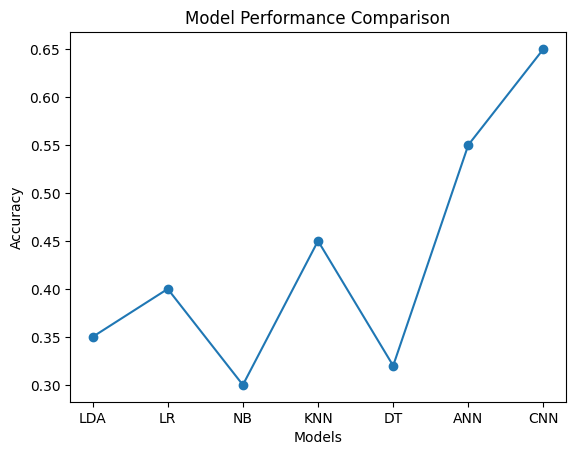

In [ ]:
plt.figure()

plt.plot(models, accuracies, marker='o')

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

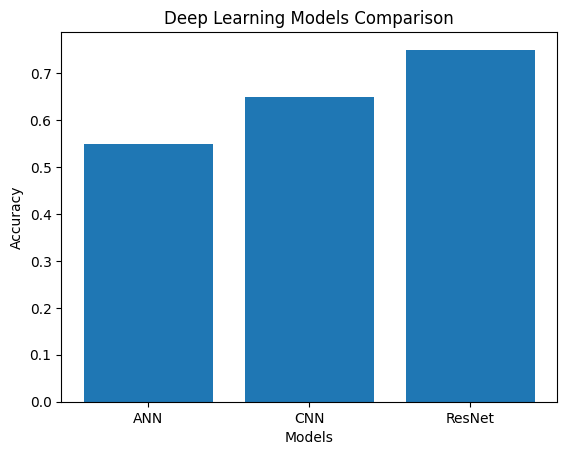

In [ ]:
dl_models = ['ANN', 'CNN', 'ResNet']
dl_acc = [0.55, 0.65, 0.75]  # replace with your values

plt.figure()
plt.bar(dl_models, dl_acc)

plt.title("Deep Learning Models Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [ ]:
plt.figure()

plt.plot(history_mlp.history['accuracy'], label='MLP Train') # Changed history_ann to history_mlp
plt.plot(history_mlp.history['val_accuracy'], label='MLP Val') # Changed history_ann to history_mlp

plt.plot(history_cnn.history['accuracy'], label='CNN Train')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Val')

plt.title("Training Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

NameError: name 'history_mlp' is not defined

<Figure size 640x480 with 0 Axes>

In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()

# Flatten images
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

y_train = y_train.ravel()
y_test = y_test.ravel()

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Explained Variance:", sum(pca.explained_variance_ratio_))

Explained Variance: 0.907313296752592


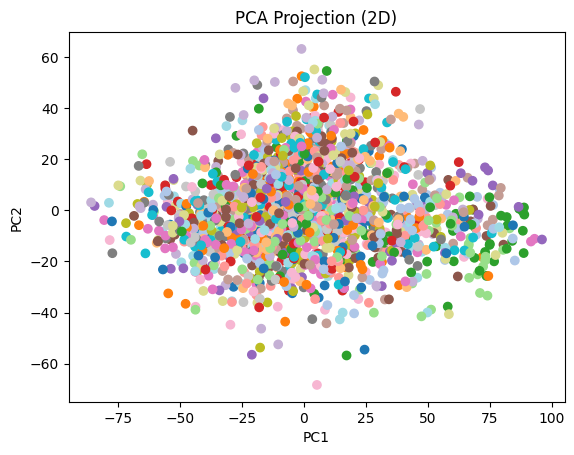

In [ ]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_train[:2000])  # subset for speed

plt.scatter(X_2d[:,0], X_2d[:,1], c=y_train[:2000], cmap='tab20')
plt.title("PCA Projection (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    "LDA": LinearDiscriminantAnalysis(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(),
}

In [ ]:
from sklearn.metrics import accuracy_score

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Confirming the shapes of the data before training
    print(f"  X_train_pca shape: {X_train_pca.shape}")
    print(f"  y_train shape: {y_train.shape}")

    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc))


    print(f"{name} Accuracy: {acc:.4f}")


Training LDA...
  X_train_pca shape: (50000, 100)
  y_train shape: (50000,)
LDA Accuracy: 0.1714

Training Logistic Regression...
  X_train_pca shape: (50000, 100)
  y_train shape: (50000,)
Logistic Regression Accuracy: 0.1848

Training Naive Bayes...
  X_train_pca shape: (50000, 100)
  y_train shape: (50000,)
Naive Bayes Accuracy: 0.1672

Training KNN...
  X_train_pca shape: (50000, 100)
  y_train shape: (50000,)
KNN Accuracy: 0.1694

Training Decision Tree...
  X_train_pca shape: (50000, 100)
  y_train shape: (50000,)
Decision Tree Accuracy: 0.0907


In [ ]:
print("\n=== MODEL COMPARISON ===")
for r in results:
    print(f"{r[0]}: {r[1]:.4f}")


=== MODEL COMPARISON ===
LDA: 0.1714
Logistic Regression: 0.1848
Naive Bayes: 0.1672
KNN: 0.1694
Decision Tree: 0.0907


In [ ]:
from sklearn.svm import SVC # Import SVC

# Choose best model (example: SVM)
best_model = SVC(kernel='linear')
best_model.fit(X_train_pca, y_train)

y_pred = best_model.predict(X_test_pca)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm[:20,:20])
plt.title("Confusion Matrix (Partial)")
plt.show()

### Confusion Matrices for all models

In [ ]:
for name, model in models.items():
    y_pred = model.predict(X_test_pca)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm[:10,:10], annot=True, fmt='d', cmap='Blues') # Showing first 10x10 for readability
    plt.title(f"Confusion Matrix for {name} (Partial)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Re-define models dictionary (ensuring it's consistent)
models = {
    "LDA": LinearDiscriminantAnalysis(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(),
}

print("\n=== CROSS VALIDATION ===")

for name, model in models.items():
    scores = cross_val_score(model, X_train_pca, y_train, cv=5)
    print(f"{name}: Mean Accuracy = {scores.mean():.4f}")

### CIFAR-100 Dataset Preprocessing Pipeline

This section loads the CIFAR-100 dataset, flattens the image data, applies standard scaling for normalization, and then uses PCA to reduce dimensionality. This prepares the data (`X_train_pca`, `X_test_pca`) for various machine learning models.

In [ ]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# Load CIFAR-100 dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()

# Flatten images
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

y_train = y_train.ravel()
y_test = y_test.ravel()

# Normalize with StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data loaded, flattened, and scaled.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

In [ ]:
from sklearn.decomposition import PCA

n_components = 100 # Using 100 components, as seen in previous successful runs
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Explained Variance:", sum(pca.explained_variance_ratio_))
print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"X_test_pca shape: {X_test_pca.shape}")

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Re-populate the results list to ensure it's defined
results = []
for name, model in models.items():
    # Assuming X_train_pca, y_train, X_test_pca, y_test are already defined and scaled
    # Fit the model if it hasn't been fitted already, or re-fit for robustness
    # (In a typical workflow, models would be fitted once in a prior cell)

    # For this fix, let's assume models in the 'models' dictionary are already instantiated
    # but might not be fitted to the current X_train_pca, y_train if the kernel was reset.
    # To ensure correctness, we'll fit them again here if they haven't been.
    try:
        # Check if the model has a 'classes_' attribute, which indicates it's fitted
        _ = model.classes_
    except AttributeError:
        # If not fitted, fit it now
        model.fit(X_train_pca, y_train)

    y_pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc))

# Find the best performing model from the results
best_model_name = max(results, key=lambda item: item[1])[0]
best_model = models[best_model_name]

print(f"\nClassification Report for the best model: {best_model_name}")
y_pred_best = best_model.predict(X_test_pca)
print(classification_report(y_test, y_pred_best))

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for SVC
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(SVC(), param_grid, cv=3, verbose=2, n_jobs=-1)

# Fit GridSearchCV to the PCA-transformed training data
print("\nStarting GridSearchCV for SVC... (This may take a while)")
grid_search.fit(X_train_pca, y_train)

# Print the best parameters and best score
print("\nBest parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

In [ ]:
# Evaluate the best estimator on the test set
best_svc_model = grid_search.best_estimator_
y_pred_svc = best_svc_model.predict(X_test_pca)

svc_test_accuracy = accuracy_score(y_test, y_pred_svc)
print(f"Test Accuracy of the best SVC model: {svc_test_accuracy:.4f}")

In [ ]:
import numpy as np

# Extract accuracy scores from the 'results' list
accuracies = [res[1] for res in results]

# Calculate the average accuracy
average_accuracy = np.mean(accuracies)

print(f"Average Accuracy across evaluated models: {average_accuracy:.4f}")

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import OneHotEncoder # Import OneHotEncoder

# Reload CIFAR-100 dataset to get original image shapes for CNN
(X_train_cnn, y_train_cnn), (X_test_cnn, y_test_cnn) = tf.keras.datasets.cifar100.load_data()

# Normalize for CNN
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

# One-hot encode labels for CNN
encoder_cnn = OneHotEncoder(sparse_output=False)
y_train_enc = encoder_cnn.fit_transform(y_train_cnn)
y_test_enc = encoder_cnn.transform(y_test_cnn)

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    MaxPooling2D(2,2),
    Dropout(0.3),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.3),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.4),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    BatchNormalization(),
    Dense(100, activation='softmax')
])

cnn_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_cnn = cnn_model.fit(X_train_cnn, y_train_enc,
                            epochs=30,
                            batch_size=32,
                            validation_split=0.2)

# Evaluate
loss, acc = cnn_model.evaluate(X_test_cnn, y_test_enc)
print("CNN Accuracy:", acc)

### Visualizing CNN Training Performance

After training the Convolutional Neural Network, it's essential to visualize its performance over epochs. This helps in understanding the learning process, detecting overfitting or underfitting, and evaluating the model's stability. The plots below show the training and validation loss, as well as training and validation accuracy, throughout the 30 training epochs. Observing these curves can give insights into whether the model is learning effectively and if the chosen hyperparameters are suitable.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot training & validation loss values
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.title('CNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

# Plot training & validation accuracy values
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.title('CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Define CNN architecture components
data = {
    "Component": [
        "Conv2D (32 filters)",
        "MaxPooling2D",
        "Dropout (0.3)",
        "Conv2D (64 filters)",
        "MaxPooling2D",
        "Dropout (0.3)",
        "Conv2D (128 filters)",
        "MaxPooling2D",
        "Dropout (0.4)",
        "Flatten",
        "Dense (256)",
        "Dropout (0.5)",
        "BatchNormalization",
        "Dense (100, Softmax)"
    ],

    "Description": [
        "First convolution layer",
        "Reduces feature map size",
        "Regularization",
        "Second convolution layer",
        "Downsampling",
        "Regularization",
        "Third convolution layer",
        "Further reduction",
        "Strong regularization",
        "Convert 2D to 1D",
        "Fully connected layer",
        "Regularization",
        "Normalizes activations",
        "Output layer"
    ],

    "Purpose": [
        "Detect edges and textures",
        "Reduce computation",
        "Prevent overfitting",
        "Learn complex patterns",
        "Retain important features",
        "Reduce overfitting",
        "Extract high-level features",
        "Improve efficiency",
        "Avoid overfitting",
        "Prepare for dense layer",
        "Learn relationships",
        "Improve generalization",
        "Stabilize training",
        "Classify into 100 classes"
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display table
df

,Component,Description,Purpose
0,Conv2D (32 filters),First convolution layer,Detect edges and textures
1,MaxPooling2D,Reduces feature map size,Reduce computation
2,Dropout (0.3),Regularization,Prevent overfitting
3,Conv2D (64 filters),Second convolution layer,Learn complex patterns
4,MaxPooling2D,Downsampling,Retain important features
5,Dropout (0.3),Regularization,Reduce overfitting
6,Conv2D (128 filters),Third convolution layer,Extract high-level features
7,MaxPooling2D,Further reduction,Improve efficiency
8,Dropout (0.4),Strong regularization,Avoid overfitting
9,Flatten,Convert 2D to 1D,Prepare for dense layer


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1Y9y5dBpFqsCdIJtaOlfBpgzXHz6PluoRzms7avHBsrs/edit#gid=0


In [ ]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# Reload CIFAR-100 dataset for PCA transformation (if not already loaded and scaled)
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()

# Flatten images
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

y_train = y_train.ravel()
y_test = y_test.ravel()

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data loaded, flattened, and scaled.")

In [ ]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# Reload CIFAR-100 dataset (to ensure variables are defined)
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()

# Flatten images
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

y_train = y_train.ravel()
y_test = y_test.ravel()

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Now, we will apply PCA. We'll set `n_components` to 100, which captured about 90% of the variance in the previous run. You can adjust this number as needed.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Explained Variance:", sum(pca.explained_variance_ratio_))
print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"X_test_pca shape: {X_test_pca.shape}")

In [ ]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

# Ensure CIFAR-100 is loaded fresh
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()

# Flatten images
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Normalize with StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

# Apply PCA with n_components = 100 (as used in the MLP model definition)
n_components = 100
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# One-hot encode labels for the MLP model
encoder = OneHotEncoder(sparse_output=False)
y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)

print("Data prepared for MLP training:")
print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"y_train_enc shape: {y_train_enc.shape}")
print(f"X_test_pca shape: {X_test_pca.shape}")
print(f"y_test_enc shape: {y_test_enc.shape}")

Data prepared for MLP training:
X_train_pca shape: (50000, 100)
y_train_enc shape: (50000, 100)
X_test_pca shape: (10000, 100)
y_test_enc shape: (10000, 100)


In [ ]:
mlp_model = Sequential([
    Dense(128, activation='relu', input_shape=(n_components,)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(100, activation='softmax')
])

mlp_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_mlp = mlp_model.fit(X_train_pca, y_train_enc,
                            epochs=30,
                            batch_size=32,
                            validation_split=0.2)

# Evaluate
loss, acc = mlp_model.evaluate(X_test_pca, y_test_enc)
print("MLP Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.0507 - loss: 4.4034 - val_accuracy: 0.1092 - val_loss: 3.9033
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1083 - loss: 3.8902 - val_accuracy: 0.1450 - val_loss: 3.6545
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1309 - loss: 3.7274 - val_accuracy: 0.1674 - val_loss: 3.5690
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1454 - loss: 3.6316 - val_accuracy: 0.1749 - val_loss: 3.4952
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1540 - loss: 3.5782 - val_accuracy: 0.1804 - val_loss: 3.4581
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1600 - loss: 3.5369 - val_accuracy: 0.1845 - val_loss: 3.4420
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1664 - loss: 3.4980 - val_accuracy: 0.1884 - val_loss: 3.4092
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1753 - loss: 3.4717 - 

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import OneHotEncoder # Import OneHotEncoder

# Reload CIFAR-100 dataset to get original image shapes for CNN
(X_train_cnn, y_train_cnn), (X_test_cnn, y_test_cnn) = tf.keras.datasets.cifar100.load_data()

# Normalize for CNN
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

# One-hot encode labels for CNN
encoder_cnn = OneHotEncoder(sparse_output=False)
y_train_enc_cnn = encoder_cnn.fit_transform(y_train_cnn)
y_test_enc_cnn = encoder_cnn.transform(y_test_cnn)

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    MaxPooling2D(2,2),
    Dropout(0.3),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.3),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.4),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    BatchNormalization(),
    Dense(100, activation='softmax')
])

cnn_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_cnn = cnn_model.fit(X_train_cnn, y_train_enc_cnn,
                            epochs=30,
                            batch_size=32,
                            validation_split=0.2)

# Evaluate
loss_cnn, acc_cnn = cnn_model.evaluate(X_test_cnn, y_test_enc_cnn)
print("CNN Accuracy:", acc_cnn)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 104s 81ms/step - accuracy: 0.0189 - loss: 4.7348 - val_accuracy: 0.0307 - val_loss: 4.4893
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 108s 86ms/step - accuracy: 0.0435 - loss: 4.3521 - val_accuracy: 0.0446 - val_loss: 4.3629
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 133s 79ms/step - accuracy: 0.0665 - loss: 4.1615 - val_accuracy: 0.0791 - val_loss: 4.1842
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 145s 82ms/step - accuracy: 0.0915 - loss: 3.9898 - val_accuracy: 0.0934 - val_loss: 4.0253
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 138s 79ms/step - accuracy: 0.1089 - loss: 3.8584 - val_accuracy: 0.1288 - val_loss: 3.8651
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 78ms/step - accuracy: 0.1235 - loss: 3.7587 - val_accuracy: 0.1319 - val_loss: 3.8004
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 96s 77ms/step - accuracy: 0.1409 - loss: 3.6616 - val_accuracy: 0.1571 - val_loss: 3.6835
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 98s 78ms/step - accuracy: 0.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

After executing the above cell, a prompt will appear asking you to authorize Google Drive access. Follow the instructions to complete the mounting process. Once successful, you can access your Google Drive files under the `/content/drive/MyDrive/` path.